In [4]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../data/processed/concrete_clean.csv")

In [8]:
df.shape

(1005, 11)

In [9]:
df.head()

,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength,mix_id,age_stage
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111,0,28-day
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366,1,28-day
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535,2,Later
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780,2,Later
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075,3,Later


In [10]:
df['age_stage'].value_counts()

age_stage
28-day    419
Early     315
Later     271
Name: count, dtype: int64

In [11]:
df['strength'].describe()

count    1005.000000
mean       35.250273
std        16.284808
min         2.331808
25%        23.523542
50%        33.798114
75%        44.868340
max        82.599225
Name: strength, dtype: float64

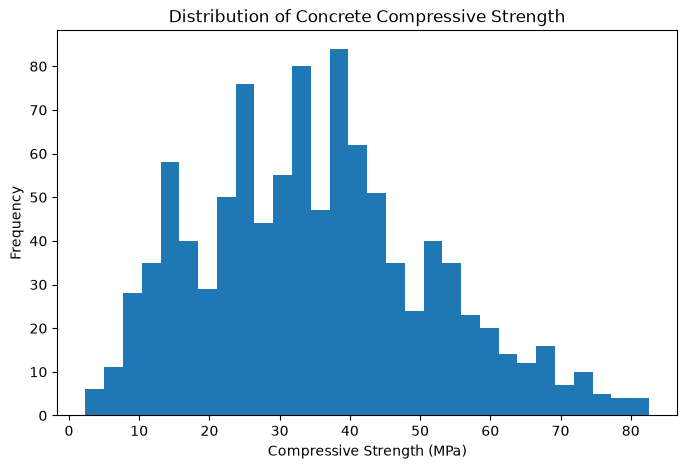

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['strength'], bins=30)
plt.xlabel('Compressive Strength (MPa)')
plt.ylabel('Frequency')
plt.title('Distribution of Concrete Compressive Strength')
plt.show()

In [13]:
df.groupby('age_stage')['strength'].describe()

,count,mean,std,min,25%,50%,75%,max
age_stage,,,,,,,,
28-day,419.0,36.429421,14.405140,8.535713,26.213878,33.729166,44.205754,81.751169
Early,315.0,22.998158,12.056131,2.331808,13.553374,21.179324,30.330394,59.763780
Later,271.0,47.668551,12.797121,21.859147,38.631340,45.367521,55.227028,82.599225


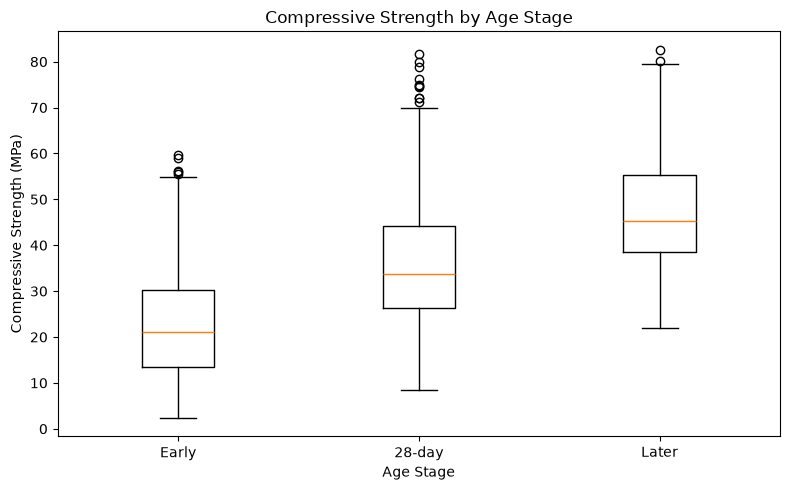

In [14]:
stage_order = ['Early', '28-day', 'Later']

strength_by_stage = [
    df.loc[df['age_stage'] == stage, 'strength']
    for stage in stage_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    strength_by_stage,
    tick_labels=stage_order
)

plt.title('Compressive Strength by Age Stage')
plt.xlabel('Age Stage')
plt.ylabel('Compressive Strength (MPa)')
plt.tight_layout()

plt.savefig(
    'fig_strength_by_stage.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [15]:
material_cols = [
    'cement',
    'slag',
    'fly_ash',
    'water',
    'superplasticizer',
    'coarse_aggregate',
    'fine_aggregate'
]

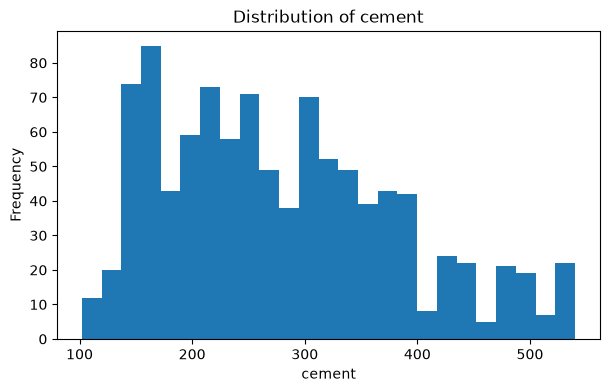

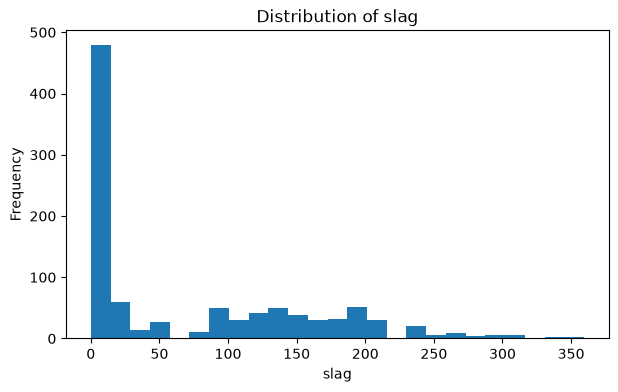

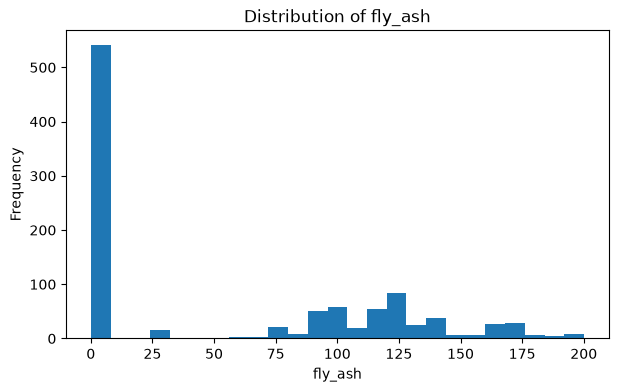

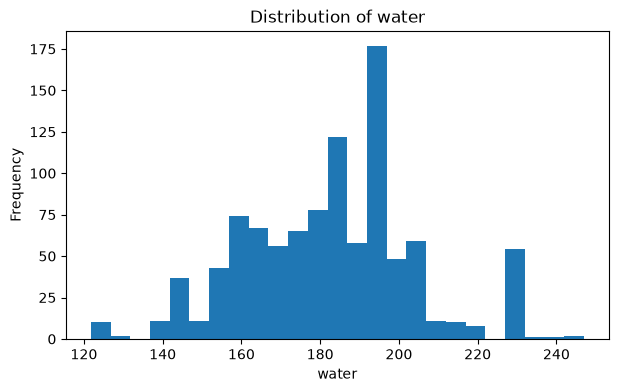

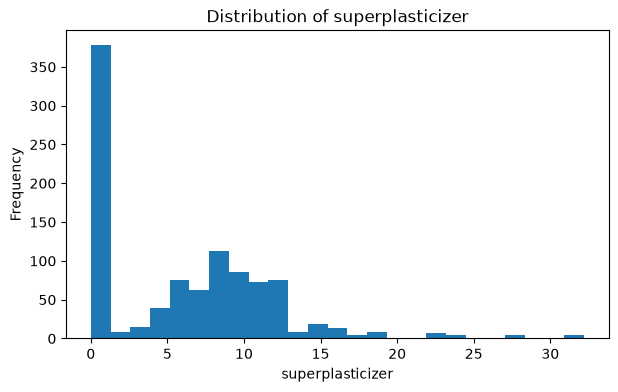

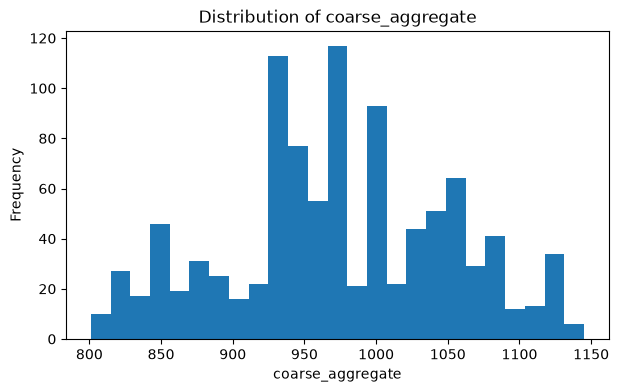

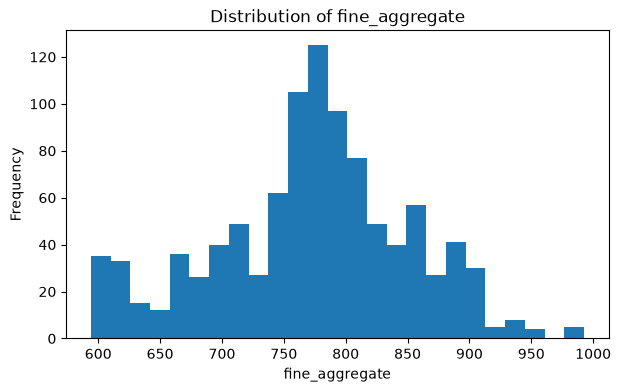

In [17]:
for col in material_cols:
    plt.figure(figsize=(7,4))
    plt.hist(df[col], bins=25)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [18]:
numeric_cols = [
    'cement',
    'slag',
    'fly_ash',
    'water',
    'superplasticizer',
    'coarse_aggregate',
    'fine_aggregate',
    'age',
    'strength'
]

corr = df[numeric_cols].corr()
corr

,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
cement,1.000000,-0.303301,-0.385618,-0.056583,0.061296,-0.086212,-0.245379,0.086349,0.488283
slag,-0.303301,1.000000,-0.312342,0.130295,0.019902,-0.277558,-0.289676,-0.042759,0.103370
fly_ash,-0.385618,-0.312342,1.000000,-0.283372,0.414055,-0.026485,0.090229,-0.158940,-0.080648
water,-0.056583,0.130295,-0.283372,1.000000,-0.646875,-0.212495,-0.444888,0.279269,-0.269606
superplasticizer,0.061296,0.019902,0.414055,-0.646875,1.000000,-0.242031,0.207794,-0.194094,0.344225
coarse_aggregate,-0.086212,-0.277558,-0.026485,-0.212495,-0.242031,1.000000,-0.162212,-0.005263,-0.144710
fine_aggregate,-0.245379,-0.289676,0.090229,-0.444888,0.207794,-0.162212,1.000000,-0.156572,-0.186457
age,0.086349,-0.042759,-0.158940,0.279269,-0.194094,-0.005263,-0.156572,1.000000,0.337371
strength,0.488283,0.103370,-0.080648,-0.269606,0.344225,-0.144710,-0.186457,0.337371,1.000000


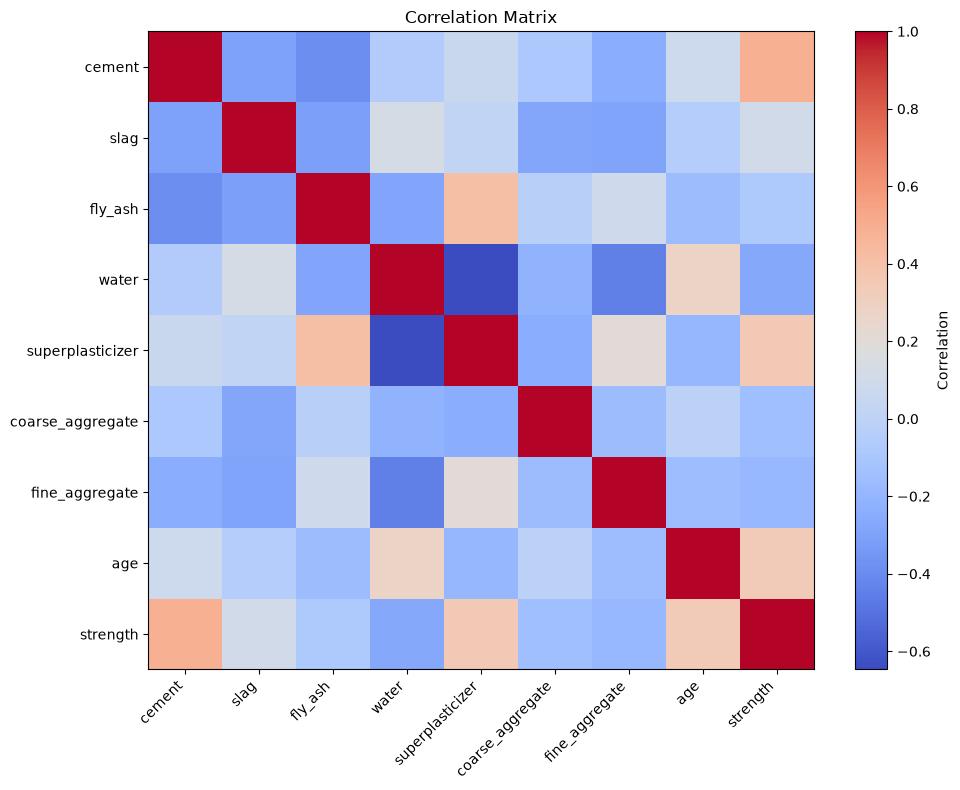

In [19]:
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [20]:
corr['strength'].sort_values(ascending=False)

strength            1.000000
cement              0.488283
superplasticizer    0.344225
age                 0.337371
slag                0.103370
fly_ash            -0.080648
coarse_aggregate   -0.144710
fine_aggregate     -0.186457
water              -0.269606
Name: strength, dtype: float64

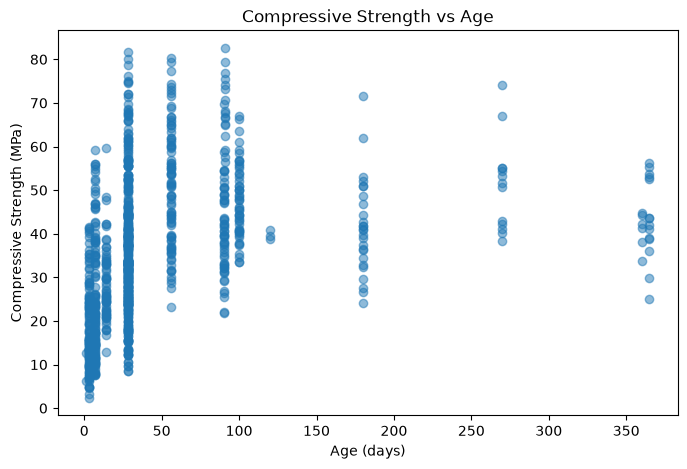

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['strength'], alpha=0.5)
plt.xlabel('Age (days)')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Compressive Strength vs Age')
plt.show()

In [22]:
age_strength_mean = df.groupby('age')['strength'].mean()
age_strength_mean

age
1       9.452716
3      18.378023
7      25.181843
14     28.751038
28     36.429421
56     50.715152
90     40.480809
91     68.674649
100    47.668780
120    39.647168
180    41.730376
270    51.272511
360    40.696895
365    43.557843
Name: strength, dtype: float64

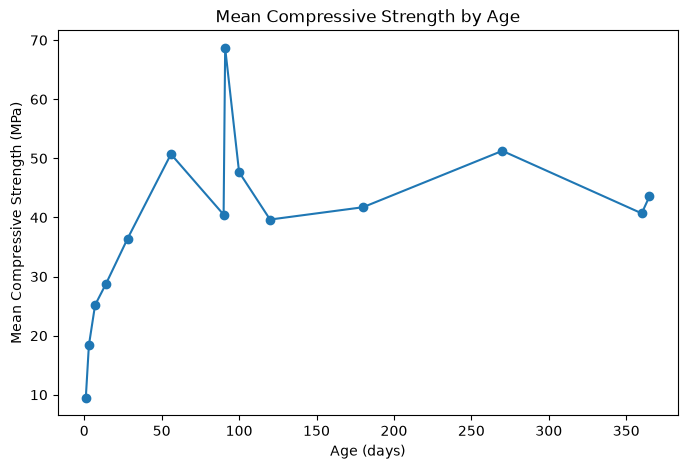

In [23]:
plt.figure(figsize=(8,5))
plt.plot(age_strength_mean.index, age_strength_mean.values, marker='o')
plt.xlabel('Age (days)')
plt.ylabel('Mean Compressive Strength (MPa)')
plt.title('Mean Compressive Strength by Age')
plt.show()

In [24]:
df['age'].value_counts().sort_index()

age
1        2
3      129
7      122
14      62
28     419
56      86
90      54
91      17
100     52
120      3
180     26
270     13
360      6
365     14
Name: count, dtype: int64

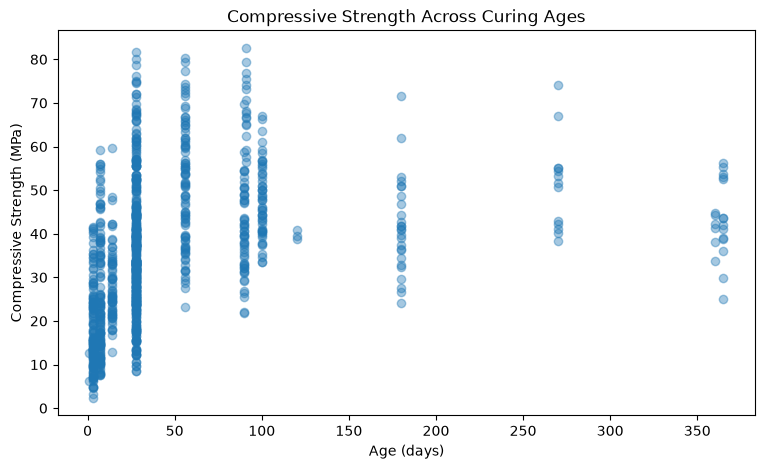

In [25]:
plt.figure(figsize=(9,5))
plt.scatter(df['age'], df['strength'], alpha=0.4)
plt.xlabel('Age (days)')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Compressive Strength Across Curing Ages')
plt.show()

In [26]:
stage_corr = {}

for stage in ['Early', '28-day', 'Later']:
    stage_data = df[df['age_stage'] == stage]
    stage_corr[stage] = stage_data[
        [
            'cement',
            'slag',
            'fly_ash',
            'water',
            'superplasticizer',
            'coarse_aggregate',
            'fine_aggregate',
            'strength'
        ]
    ].corr()['strength'].drop('strength')

stage_corr

{'Early': cement              0.626242
 slag               -0.000368
 fly_ash             0.061497
 water              -0.433243
 superplasticizer    0.560780
 coarse_aggregate   -0.188348
 fine_aggregate     -0.223278
 Name: strength, dtype: float64,
 '28-day': cement              0.662460
 slag                0.121508
 fly_ash            -0.257605
 water              -0.384796
 superplasticizer    0.189437
 coarse_aggregate   -0.107357
 fine_aggregate     -0.153461
 Name: strength, dtype: float64,
 'Later': cement              0.474310
 slag                0.322823
 fly_ash            -0.053048
 water              -0.395349
 superplasticizer    0.561033
 coarse_aggregate   -0.126180
 fine_aggregate     -0.194866
 Name: strength, dtype: float64}

In [27]:
stage_corr_df = pd.DataFrame(stage_corr)
stage_corr_df

,Early,28-day,Later
cement,0.626242,0.662460,0.474310
slag,-0.000368,0.121508,0.322823
fly_ash,0.061497,-0.257605,-0.053048
water,-0.433243,-0.384796,-0.395349
superplasticizer,0.560780,0.189437,0.561033
coarse_aggregate,-0.188348,-0.107357,-0.126180
fine_aggregate,-0.223278,-0.153461,-0.194866


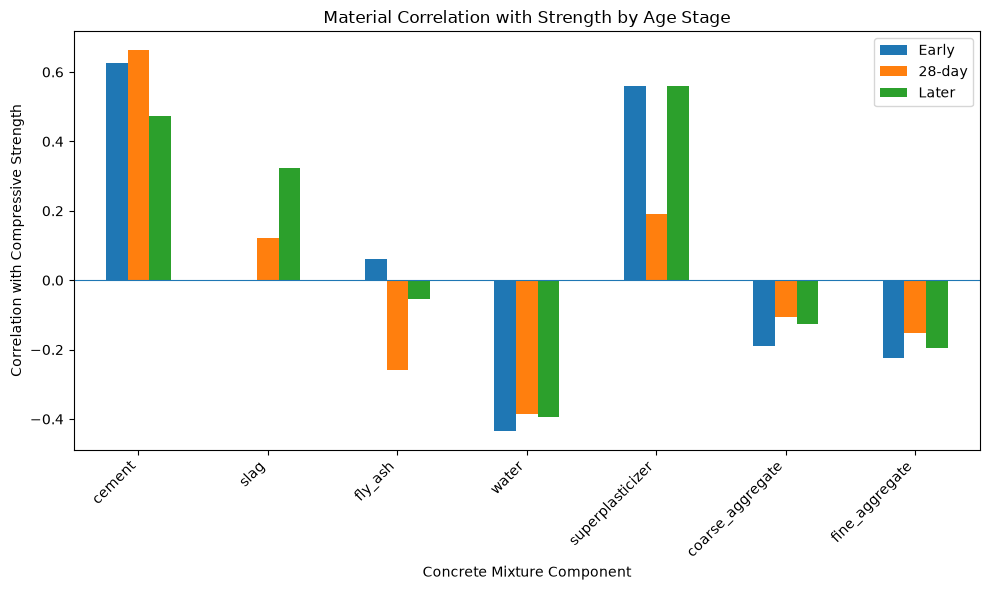

In [28]:
stage_corr_df.plot(
    kind='bar',
    figsize=(10,6)
)

plt.axhline(0, linewidth=0.8)
plt.title('Material Correlation with Strength by Age Stage')
plt.xlabel('Concrete Mixture Component')
plt.ylabel('Correlation with Compressive Strength')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

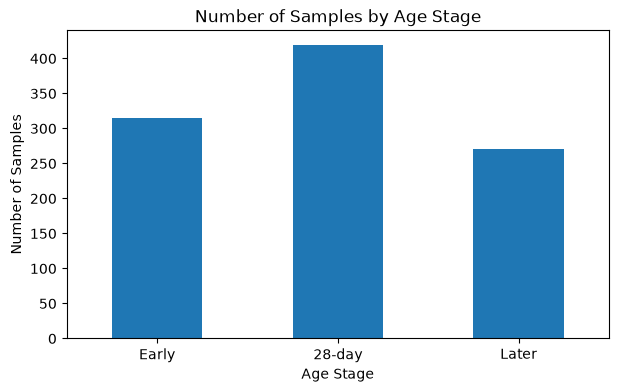

In [29]:
df['age_stage'].value_counts().reindex(['Early', '28-day', 'Later']).plot(
    kind='bar',
    figsize=(7,4)
)

plt.title('Number of Samples by Age Stage')
plt.xlabel('Age Stage')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()